In [97]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

from itertools import chain
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale as ART_down
from function import ART_statistic as ART_stat

import warnings
warnings.filterwarnings('ignore')

In [98]:
# product, time_reso, reso = 'IMERG', '1dy', '10'
product, time_reso, reso = 'CMORPH', '3h', '25'
# product, time_reso, reso = 'CHIRPS', '1dy', '5'

# product, time_reso, reso = 'ERA5', '3h', '25'
# product, time_reso, reso = 'MSWEP', '3h', '10'
# product, time_reso, reso = 'GSMaP', '3h', '10'

In [99]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy')
obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [100]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [101]:
if product == 'ENSEMBLE':
    dir_sat = os.path.join(dir_base, 'Satellite', '5_ENSEMBLE')
    inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'
elif product == 'CHIRPS':
    dir_sat = os.path.join(dir_base, 'Satellite', '5_DOWN')
    inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_MEVD.nc'
else:
    dir_sat = os.path.join(dir_base, 'Satellite', '5_DOWN')
    inputfile = f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'

data_dir = os.path.join(dir_sat, inputfile)
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
years = DATA.year.values

In [102]:
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

In [103]:
MEV = DATA.Mev_s.where(mask_italy).values

In [104]:
METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv'))
print(f'Number of Stations: {len(METADATA)}')

Number of Stations: 2910


In [105]:
pos = 3
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)
print(f'Return Time: {Tr[pos]} yrs')

Return Time: 50 yrs


In [106]:
Factor_df = []

lat_list, lon_list = [], []
factor_N_list, factor_C_list, factor_W_list = [], [], []
QUANTILE, file_list = [], []
Nval_list = []

for nn in range(len(METADATA)):
    file = METADATA['File'].values[nn]
    ISO = METADATA['ISO'].values[nn]
    lon_obs = METADATA['Lon'].values[nn]
    lat_obs = METADATA['Lat'].values[nn]

    DF_OBS = pd.read_csv(os.path.join(obs_base,'Weibull','1dy',ISO,file)) 
    DF_OBS = DF_OBS.drop(columns='NaN')

    sat_pixel = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

    sat_n = sat_pixel.NYs.values
    sat_year = sat_pixel.year.values

    DF_SAT = pd.DataFrame({'Year':sat_pixel.year.values, 'Ns':sat_pixel.NYs.values, 'Cs':sat_pixel.CYs.values, 'Ws':sat_pixel.WYs.values})

    merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')
    merged_df_clean = merged_df.dropna(subset=['N'])

    # Model 1: Nobs_mean/ Nsat_mean
    # factor_N = np.nanmean(merged_df_clean.N.values) / np.nanmean(merged_df_clean.Ns.values)
    # factor_C = np.nanmean(merged_df_clean.C.values) / np.nanmean(merged_df_clean.Cs.values)
    # factor_W = np.nanmean(merged_df_clean.W.values) / np.nanmean(merged_df_clean.Ws.values)
    
    # Model 2 np.mean(N_obs/N_sat)
    factor_N = np.nanmean(merged_df_clean.N.values/merged_df_clean.Ns.values)
    factor_C = np.nanmean(merged_df_clean.C.values/merged_df_clean.Cs.values)
    factor_W = np.nanmean(merged_df_clean.W.values/merged_df_clean.Ws.values)

    x0 = np.nanmean(merged_df_clean.C.values)
    OBS_Q, flag = DOWN_raw.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
    OBS_Q2 = np.where(flag, OBS_Q, np.nan)

    lat_list.append(lat_obs)
    lon_list.append(lon_obs)
    factor_N_list.append(factor_N)
    factor_C_list.append(factor_C)
    factor_W_list.append(factor_W)
    file_list.append(file)
    QUANTILE.append(OBS_Q2[pos])
    Nval_list.append(len(merged_df_clean.N.values))

Factor_N_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_N_list})
Factor_C_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_C_list})
Factor_W_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'factor':factor_W_list})
Quantile_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'file':file_list, 'MEV':QUANTILE, 'Nval':Nval_list})

In [107]:
factor_N_grid = ART_stat.interpolate_factors_to_grid(Factor_N_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
factor_N_grid = factor_N_grid.where(mask_italy).values

factor_C_grid = ART_stat.interpolate_factors_to_grid(Factor_C_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
factor_C_grid = factor_C_grid.where(mask_italy).values

factor_W_grid = ART_stat.interpolate_factors_to_grid(Factor_W_df, DATA, use_idw=True, power=2, n_neighbors=2, max_distance=5.0)
factor_W_grid = factor_W_grid.where(mask_italy).values

In [108]:
NYs = DATA.NYs.where(mask_italy).values
CYs = DATA.CYs.where(mask_italy).values
WYs = DATA.WYs.where(mask_italy).values

In [109]:
if product == 'CHIRPS':
    NYs = np.where(NYs==0,np.nan,NYs)
    CYs = np.where(CYs==0,np.nan,CYs)
    WYs = np.where(WYs==0,np.nan,WYs)

In [110]:
NYs_corrected = NYs*factor_N_grid
CYs_corrected = CYs*factor_C_grid
WYs_corrected = WYs*factor_W_grid

Text(0.0, 1.0, '(b) Factor gridded result')

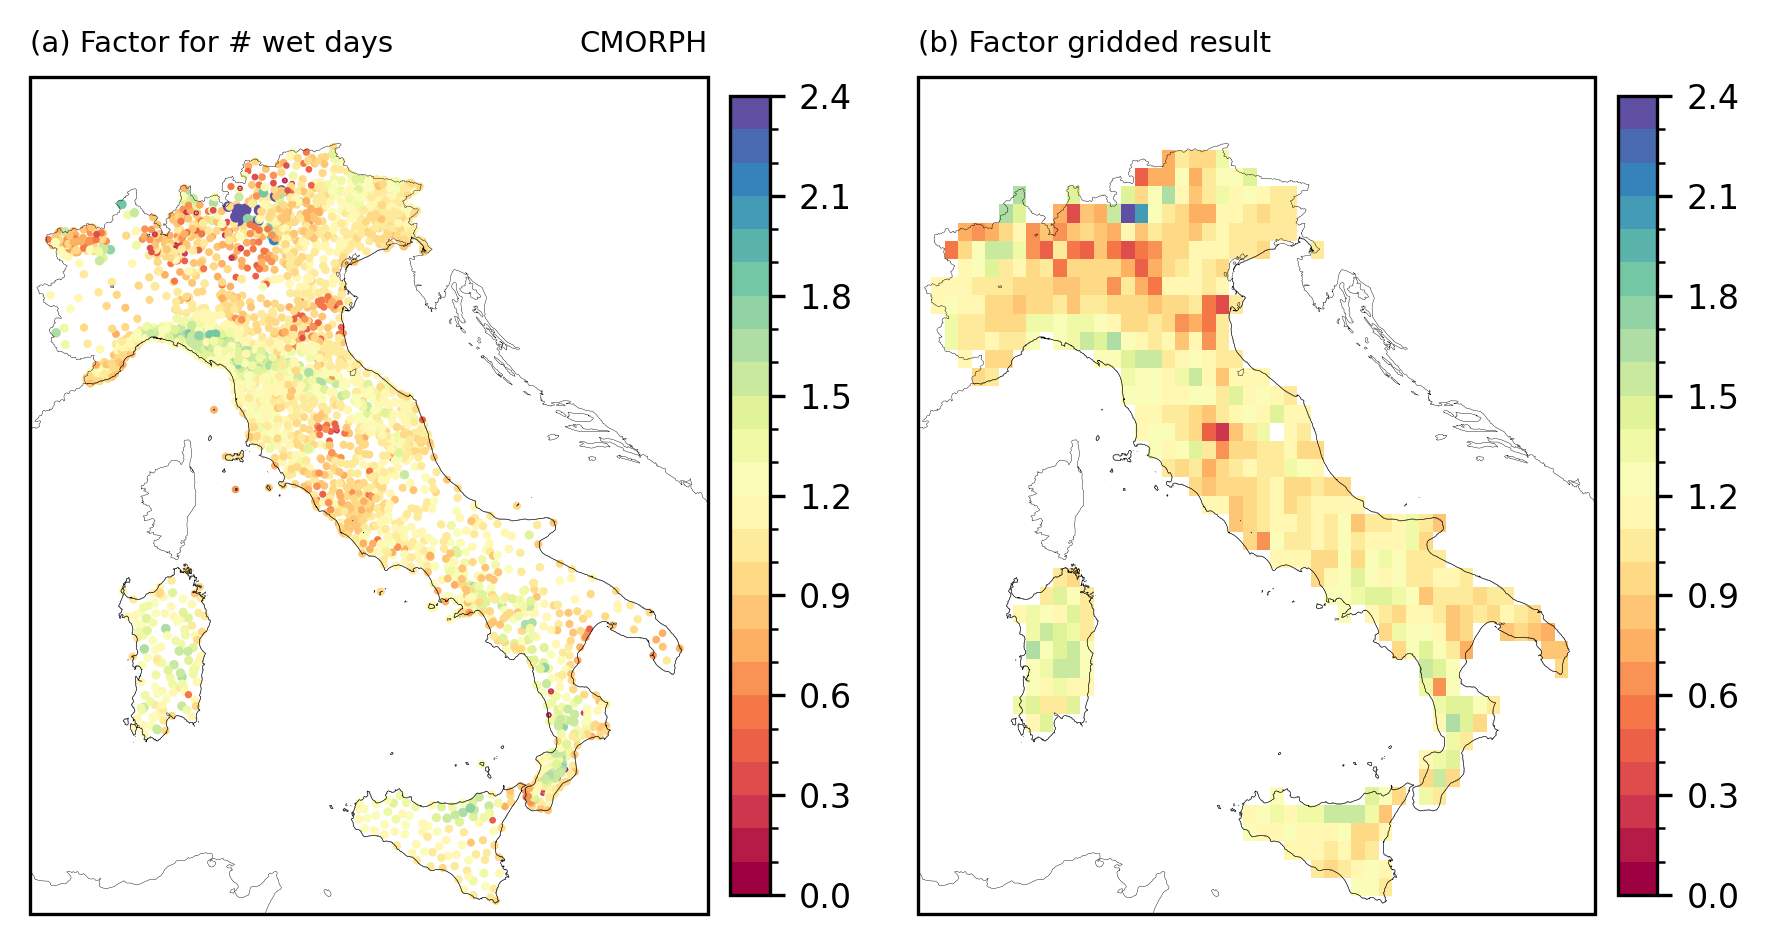

In [111]:
factor_levels = np.arange(0,2.5,0.1)
factor_norm = mcolors.BoundaryNorm(boundaries=factor_levels, ncolors=256)

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7,5),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.scatter(Factor_N_df.lon.values, Factor_N_df.lat.values, s=Factor_N_df.factor*1, c=Factor_N_df.factor, cmap='Spectral', norm=factor_norm)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(a) Factor for # wet days', loc='left', fontsize=7)
ax1.set_title(product, loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, factor_N_grid, cmap='Spectral', norm=factor_norm)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

ax1.set_title('(b) Factor gridded result', loc='left', fontsize=7)

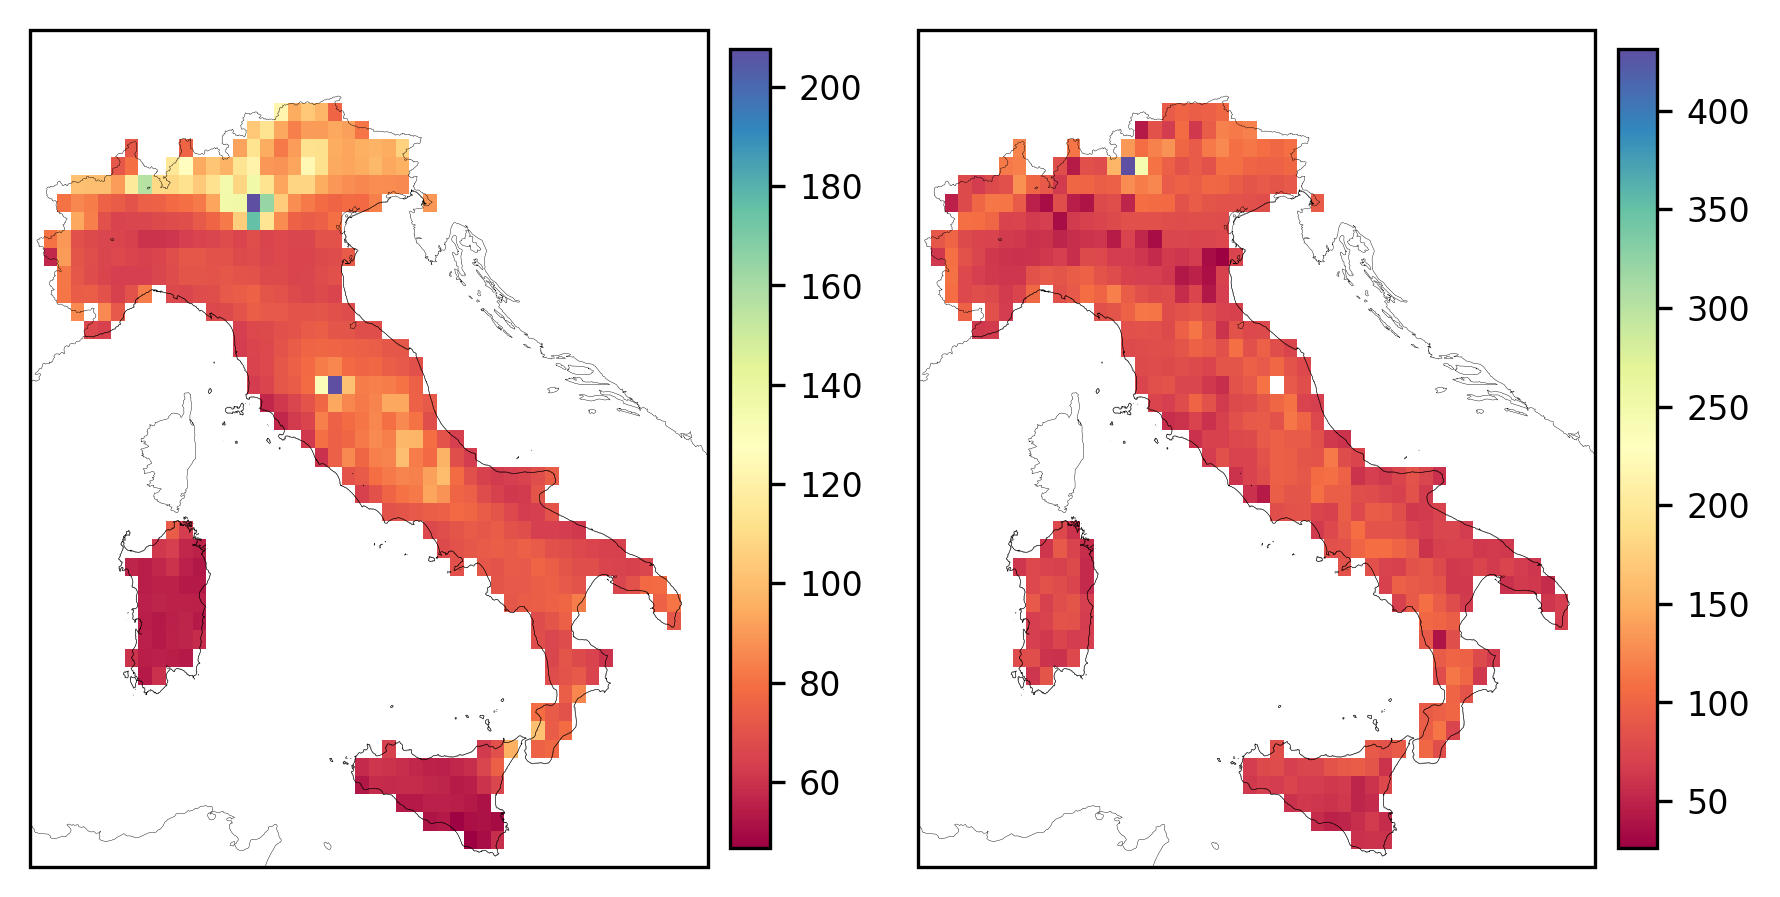

In [112]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7,5),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, np.nanmean(NYs,axis=0), cmap='Spectral', norm=None)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, np.nanmean(NYs_corrected,axis=0), cmap='Spectral', norm=None)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

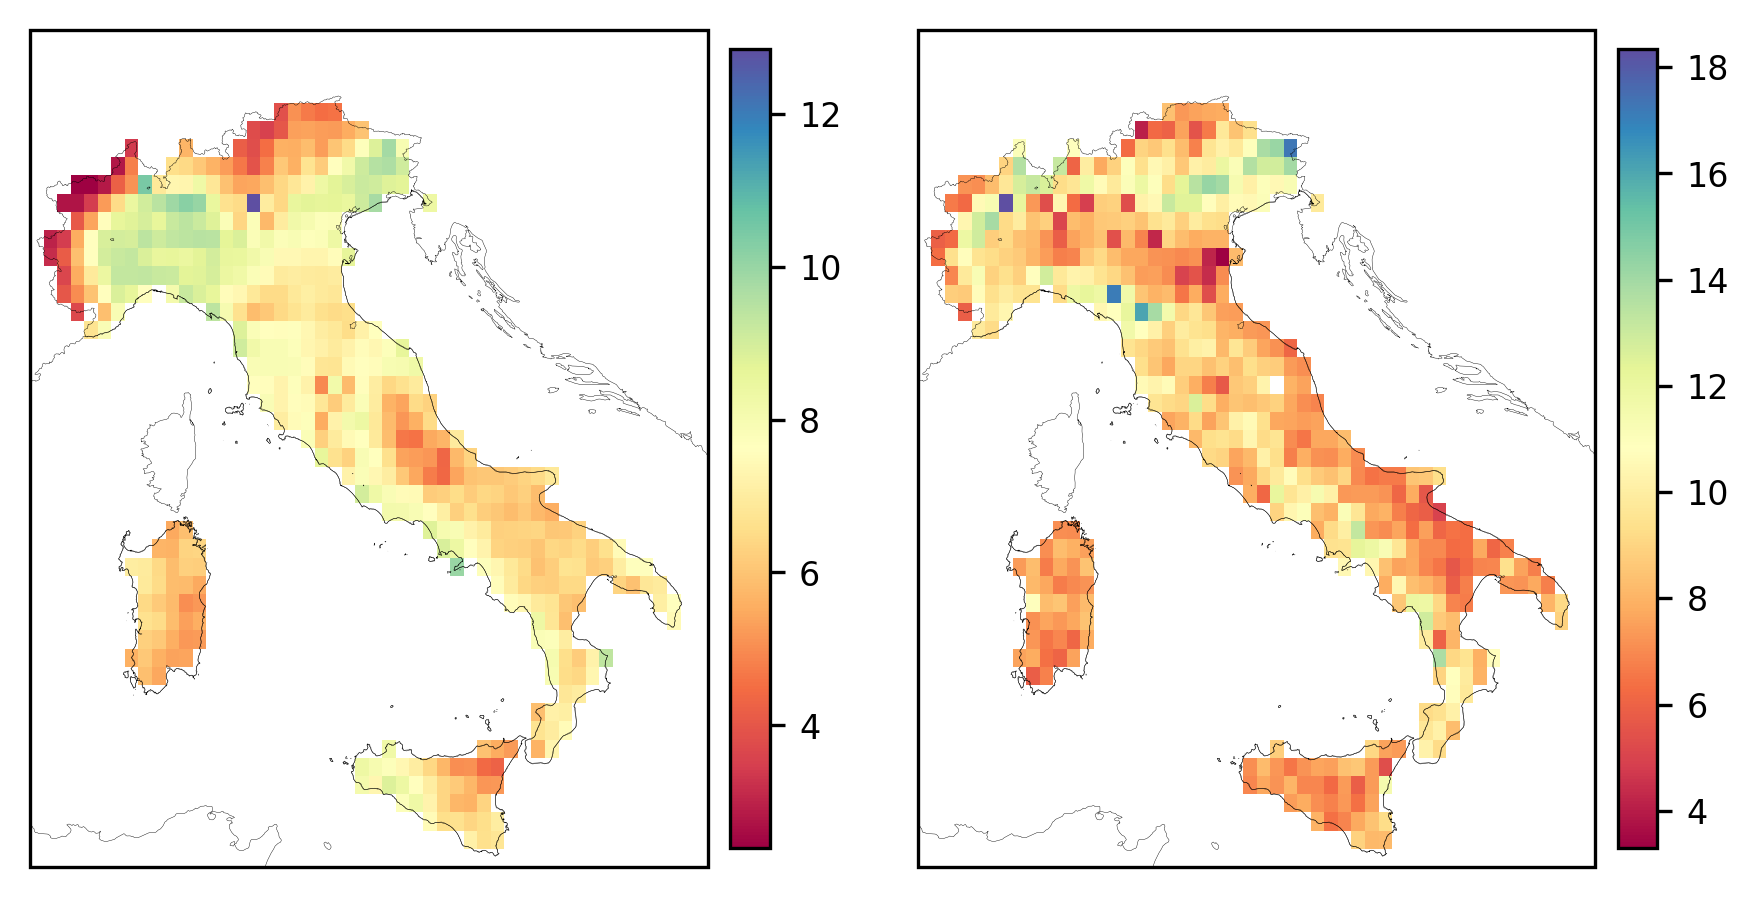

In [113]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7,5),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, np.nanmean(CYs,axis=0), cmap='Spectral', norm=None)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, np.nanmean(CYs_corrected,axis=0), cmap='Spectral', norm=None)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

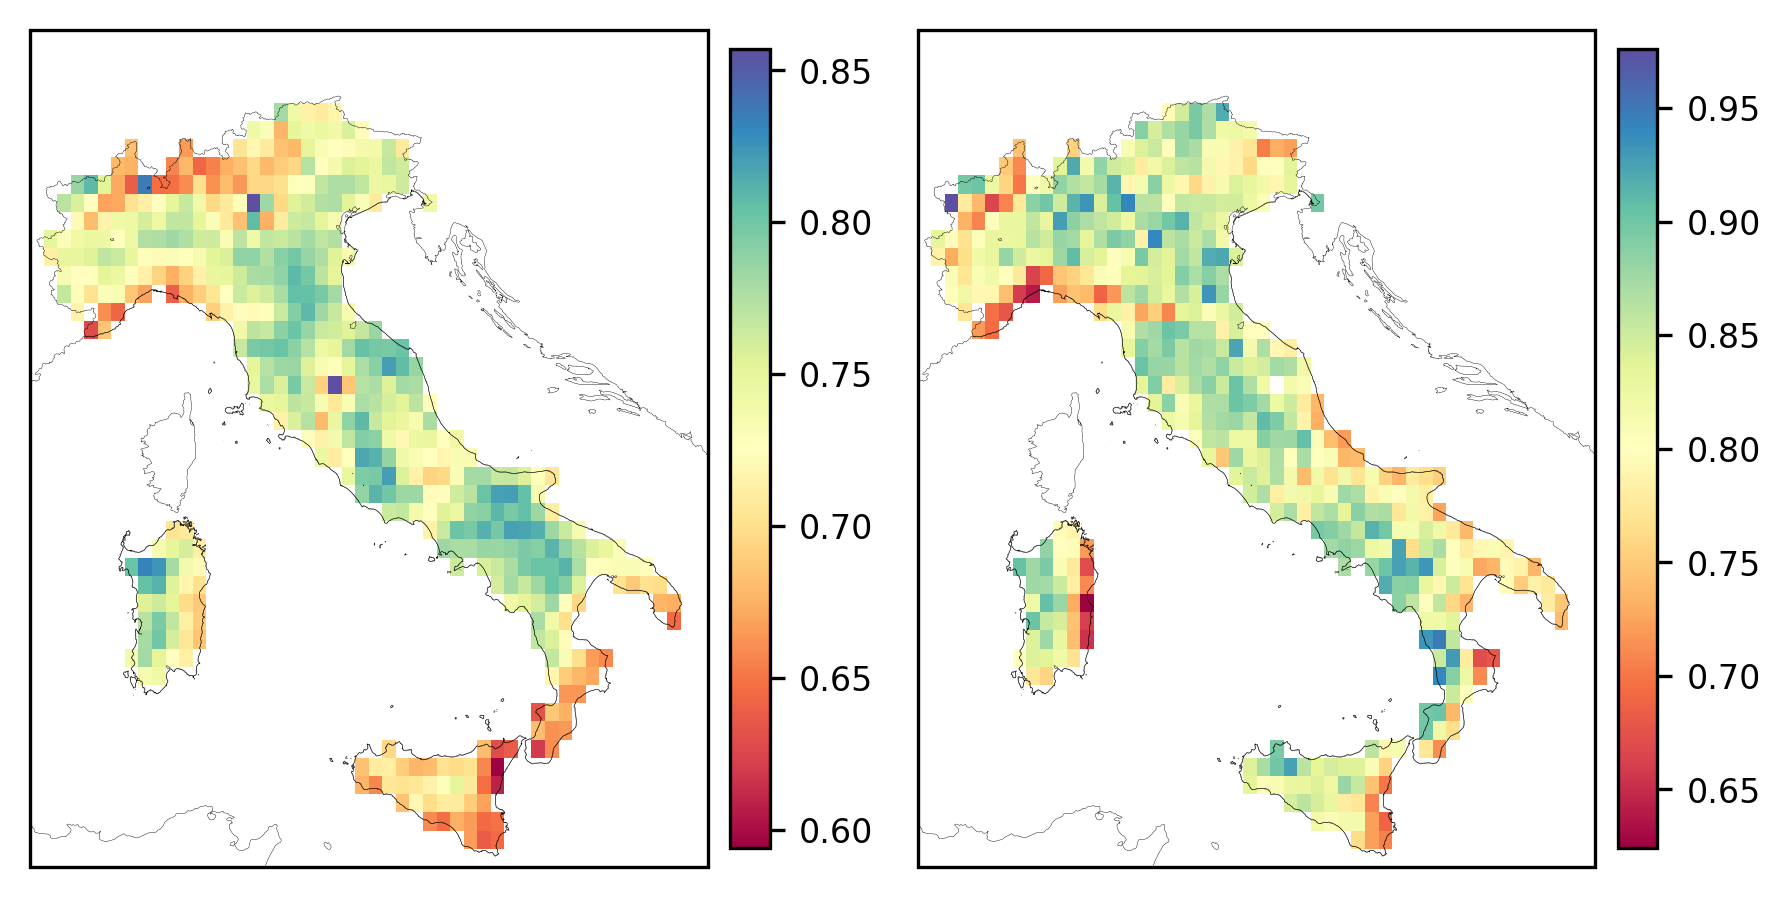

In [114]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7,5),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, np.nanmean(WYs,axis=0), cmap='Spectral', norm=None)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, np.nanmean(WYs_corrected,axis=0), cmap='Spectral', norm=None)

cbar = plt.colorbar(a1, fraction=0.054, pad=0.03)
cbar.ax.tick_params(labelsize=8)

In [115]:
Tr = [5,  10,  20,  50, 100, 200]
MEV_corrected = ART_down.pre_quantiles_array(
                            NYs_corrected, 
                            CYs_corrected, 
                            WYs_corrected, 
                            Tr, lats, lons, 1)

In [116]:
Mev_levels = np.arange(50, 510, 10)
Mev_cmap = plt.cm.Spectral_r
norm = BoundaryNorm(Mev_levels, ncolors=Mev_cmap.N, clip=True)

In [117]:
if product == 'CHIRPS':
    mask_nan_2d = np.isnan(WYs[0, :, :])
    mask_nan_3d = np.broadcast_to(mask_nan_2d, MEV_corrected.shape)
    MEV[mask_nan_3d] = np.nan

    mask_nan = np.isnan(MEV)
    MEV_corrected[mask_nan] = MEV[mask_nan]

Text(0.0, 1.0, '(c) MEV Quantiles Corrected')

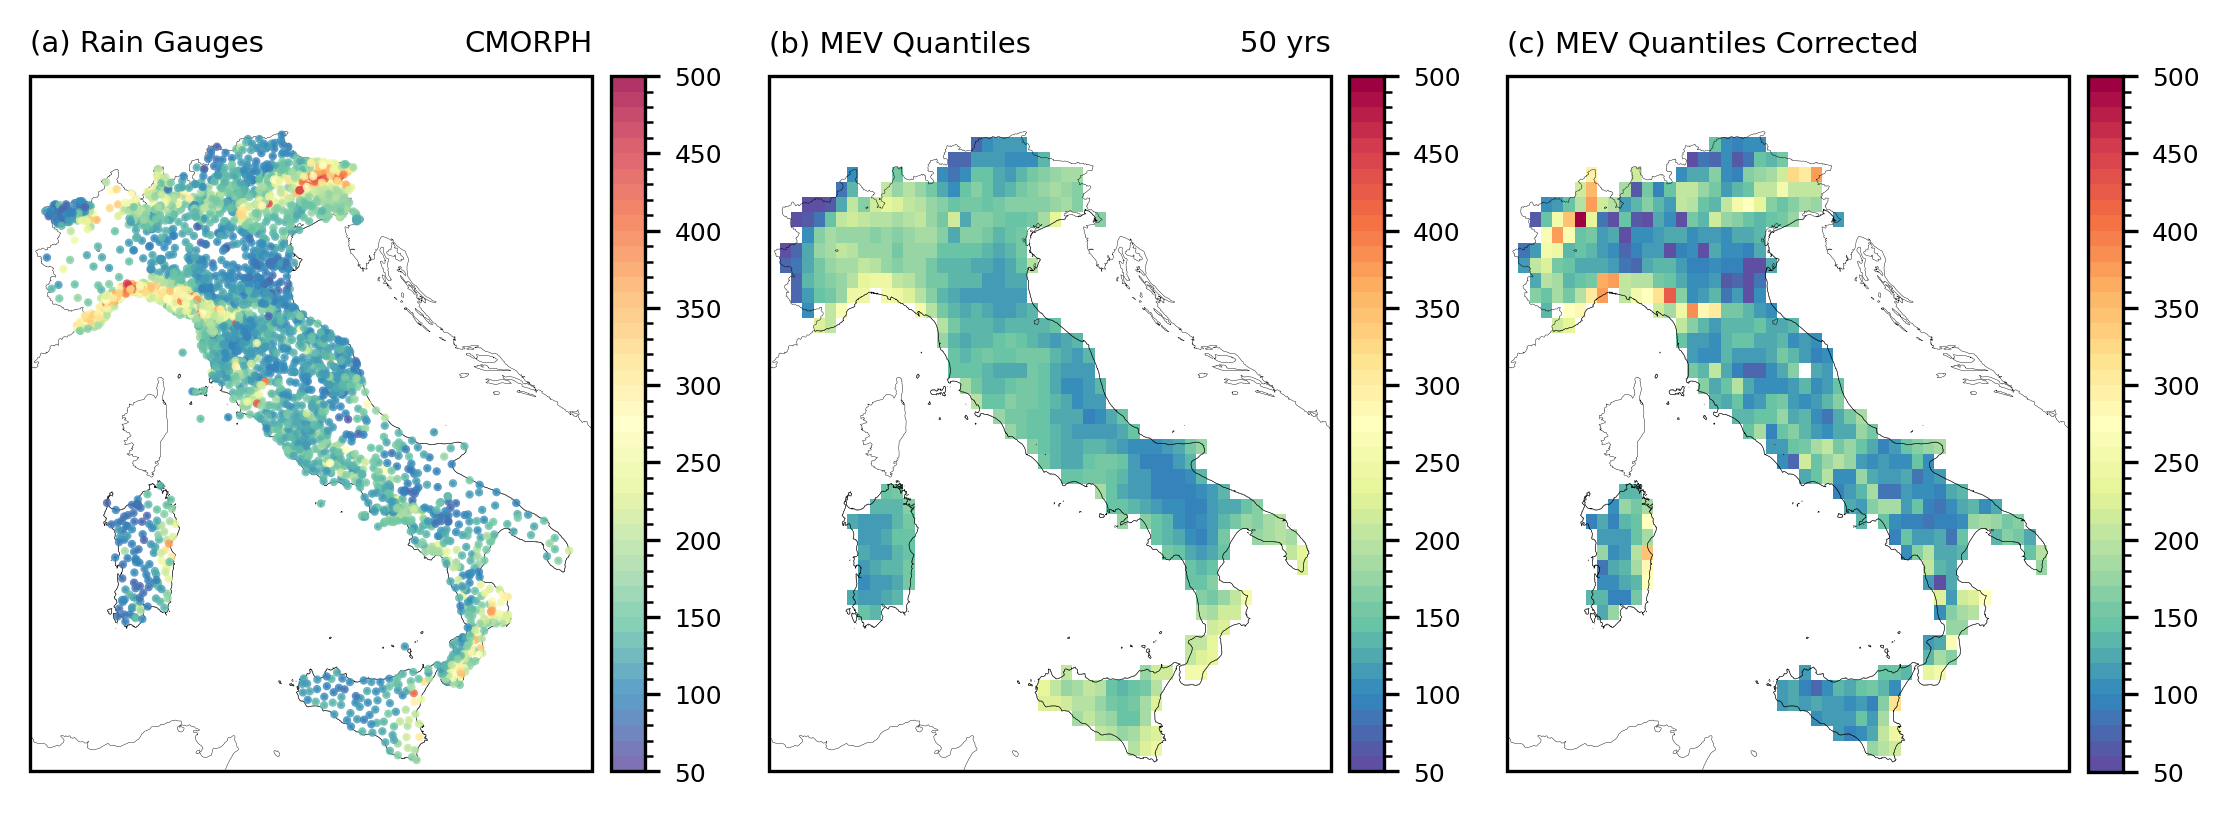

In [118]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,5),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.scatter(Quantile_df['lon'].values, Quantile_df['lat'].values, c=Quantile_df['MEV'].values, s=1, alpha=0.8,cmap='Spectral_r',norm=norm, zorder=10)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(a) Rain Gauges', loc='left', fontsize=7)
ax1.set_title(product, loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEV[3,:,:], cmap='Spectral_r', norm=norm)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(b) MEV Quantiles', loc='left', fontsize=7)
ax1.set_title(f'{Tr[pos]} yrs', loc='right', fontsize=7)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEV_corrected[3,:,:], cmap='Spectral_r', norm=norm)

cbar = plt.colorbar(a1, fraction=0.0565, pad=0.03)
cbar.ax.tick_params(labelsize=6)

ax1.set_title('(c) MEV Quantiles Corrected', loc='left', fontsize=7)

In [119]:
DOWN_corrected = xr.Dataset(
        data_vars={
            "NYs": (("year","lat","lon"), NYs_corrected),
            "CYs": (("year","lat","lon"), CYs_corrected),
            "WYs": (("year","lat","lon"), WYs_corrected),
            "MEVs": (("Tr","lat","lon"), MEV_corrected),
            },
        coords={
            'year': years, 
            'lat': lats, 
            'lon': lons
            },
            attrs=dict(description=f"{product} Weibull parameters and MEV corrected applying in Italy",))

DOWN_corrected.NYs.attrs["units"] = "# days"
DOWN_corrected.NYs.attrs["long_name"] = "Corrected MEV Number of Wet Days"
DOWN_corrected.NYs.attrs["origname"] = "MEV Wet Days"

DOWN_corrected.CYs.attrs["units"] = "nondimensional"
DOWN_corrected.CYs.attrs["long_name"] = "Corrected MEV Scale Parameter"
DOWN_corrected.CYs.attrs["origname"] = "MEV Scale"

DOWN_corrected.WYs.attrs["units"] = "nondimensional"
DOWN_corrected.WYs.attrs["long_name"] = "Corrected MEV Shape Parameter"
DOWN_corrected.WYs.attrs["origname"] = "MEV Shape"

DOWN_corrected.MEVs.attrs["units"] = "mm/day"
DOWN_corrected.MEVs.attrs["long_name"] = "Corrected MEV Extreme Quantiles"
DOWN_corrected.MEVs.attrs["origname"] = "MEV Ext-Quant"

DOWN_corrected.lat.attrs["units"] = "degrees_north"
DOWN_corrected.lat.attrs["long_name"] = "Latitude"

DOWN_corrected.lon.attrs["units"] = "degrees_east"
DOWN_corrected.lon.attrs["long_name"] = "Longitude"

PRE_out = os.path.join(os.path.join(dir_base, 'Satellite', '4_MEV','corrected',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
print(f'Exportin as: {PRE_out}')
DOWN_corrected.to_netcdf(PRE_out)
print()

Exportin as: /media/arturo/T9/Data/Italy/Satellite/4_MEV/corrected/ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc



In [120]:
pos_list = [1, 3, 4, 5]
for pos in pos_list:
    print(f'Return time: {Tr[pos]} years') 
    dir_out = os.path.join('/','home','arturo','github','downpy','output','geotiff','MEV_corrected',f'{product}_MEVc_{reso}km_{Tr[pos]}_yrs.tif')
    ART_stat.export_geotiff(MEV_corrected[pos, :, :],lats,lons,'MEV',dir_out)

Return time: 10 years
Return time: 50 years
Return time: 100 years
Return time: 200 years
